# **Architecture comparison**

This notebook explain how to reproduce the Figure n.4 of the article to chose the architecture of of our proposed residual neural network. 

*Author: Benjamin Pineau, Barbara Pascal, Sébastien Bourguignon*

### **Important remark**:

This notebook requires a GitHub repository. Please install [EpiJointSpatiotempEstim](https://github.com/elasalle/EpiJointSpatiotempEstim/) before using this notebook. 

Write the path to this toolbox on your device below.

In [1]:
import sys 
from pathlib import Path

# path to the EpiJointSpatiotempEstim repository on your device
# ======================================================================================================== #
path_EpiJointSpatiotempEstim = "/Users/benji/Documents/Centrale_Nantes/EI3/OPDOC/EpiJointSpatiotempEstim/" #
# ======================================================================================================== #

prog_python_path = Path(path_EpiJointSpatiotempEstim).resolve()

if str(prog_python_path) not in sys.path:
    sys.path.insert(0, str(prog_python_path))

Set the seed of your choice, by default the one used to generate the article data.

In [ ]:
np.random.seed(6300)

In [2]:
%run ../utils/preamble.py

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## **Creation of synthetic data**

To account for the large intrinsic variability of infection counts, we use a *scaled* Poisson model :

$$
\frac{\mathsf{Z}_t}{\gamma} \mid \mathsf{Z}_1, \, \dots, \,  \mathsf{Z}_{t-1}, \,\mathsf{R}_t \sim \mathcal{P}\left(\frac{ \Phi^{\mathsf{Z}}_t  \mathsf{R}_t}{\gamma} \right).
$$

where $\gamma = \omega \times \delta$, $\delta$ represents a reference scale and $\omega$ represents a variance level. We generate synthetic data for a specific variance level then train the $\mathsf{UnCP}$ model for different numbers of layers and filters. 

In [3]:
# define the variance levels
list_varlevel = np.logspace(np.log10(0.01), np.log10(0.05), 10)

dico_varlevel = {5: round(list_varlevel[4],4)}

In [ ]:
# Creation of training and test datasets

# train
N_replica_train = 5
dico_datasets_varlevel_train = create_synthetic_data('train', N_replica_train, dico_varlevel)

# test
N_replica_test = 200
dico_datasets_varlevel_test = create_synthetic_data('test', N_replica_test, dico_varlevel)

**Remark**: 

You can save the synthetic data created from ```create_synthetic_data```. To do so, please set ```save = True``` and ```save_path = 'path/to/folder'```such that: 

*create_synthetic_data('train', N_replica_train, dico_varlevel, save = True, save_path = 'path/to/folder')*.

The folders will be organised as follow:

```text
dataset
└── varlevel
    ├── groundTruthR1_realization1
    ├── groundTruthR1_realization2
    ├── ...
    ├── groundTruthR2_realization1
    ├── ...

## **Training of the model**


Here we focus on the training of the proposed $\mathsf{UnCP}$ model on the dataset $\mathcal{S}_{\omega^{(5)}}$ for various numbers of layers and filters. 

### Unrolled Chambolle–Pock Layer

One layer of the unrolled Chambolle–Pock algorithm applied to the estimation of the COVID-19 reproduction number can be written as:

$$
\left\{
\begin{aligned}
\boldsymbol{\mathsf{U}}^{[k+1]} &=
\mathrm{prox}_{\sigma (\lambda\lVert \cdot \rVert_1)^*} \left( \boldsymbol{\mathsf{U}^{[k]}} + \sigma \mathsf{H}_k \overline{\boldsymbol{\mathsf{R}}}^{[k]} \right), \\[0.4em]
\boldsymbol{\mathsf{R}}^{[k+1]} &=
\mathrm{prox}_{\rho \mathsf{D}_{\mathrm{KL}}\left(\boldsymbol{\mathsf{Z}} \mid \boldsymbol{\cdot} \odot \Phi^{\boldsymbol{\mathsf{Z}}}\right)}
\left(
\boldsymbol{\mathsf{R}}^{[k]} -
\rho \mathsf{H}_k^\top \boldsymbol{\mathsf{U}}^{[k+1]}
\right), \\[0.4em]
\overline{\boldsymbol{\mathsf{R}}}^{[k+1]} &= 2\boldsymbol{\mathsf{R}}^{[k+1]} - \boldsymbol{\mathsf{R}}^{[k]} .
\end{aligned}
\right.
$$

---

### Learnable Parameters

We learn a linear operator $\mathsf{H}_k$ by imposing a filter structure on it :
$$    
    \mathsf{h}^{[k]} =
    \begin{bmatrix}
    c_{1}^{[k]}  & \cdots & c_{25}^{[k]} & 0 &\cdots & 0 \\
    0 & c_{1}^{[k]} & \cdots & c_{25}^{[k]} & 0 &\cdots  \\
    \vdots & \vdots & \vdots & \ddots & \ddots & \vdots \\
    \end{bmatrix} \in \mathbb{R}^{(T - 25)\times T}
    , \quad k \in {1, \dots, k_{\text{layer}}}.
$$
Furthemore we apply $n$ filters in parallel for the same layer, which is equivalent to consider the filter $\mathsf{H}_k \in \mathbb{R}^{n(T - 25)\times T}$ such that for $x \in \mathbb{R}^T$ :
$$
    \mathsf{H}_k(x) = \big[\mathsf{h}_i^{[k]}*x\big]_{i = 1}^{n}
, \quad \text{with} \quad
    \mathsf{h}^{[k]}_i = 
    \begin{bmatrix}
    c_{1, i}^{[k]}  & \cdots & c_{25, i}^{[k]} \\
    \end{bmatrix}
    , \; i \in {1, \dots, n}
$$

---

### Config settings

It is possible to set up the following settings: 
- **`device`**: device on which to perform the calculation, basically CPU or CUDA
- **`dataset`**: training dataset, accepts a *path* or a *dictionary* from `create_synthetic_data`
- **`nepoch`**: number of epoches
- **`K_layer`**: number of layers
- **`nb_filter`**: number of filters per layer
- **`learning_rate`** = learning rate
- **`R_init_type`**: input $\mathsf{R}^{[0]}$ of the network. Choice between $\mathsf{R}^{[0]} = \mathsf{R}^{[\mathrm{MLE}]}$ and $\mathsf{R}^{[0]} = \boldsymbol{1}$
- **`nbatch`**: batch size

In [3]:
layer_list = [5, 10, 15, 20]
filter_list = [5, 10, 20, 25]

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

dico_model = {}
dico_loss = {}
dico_config = {}

for k in layer_list:
    for j in filter_list:

        print(f'Traing the UnCP model for k = {k} and j ={j}.')
    
        dico_config[f'K{k}_J{j}'] = TrainConfig(
            device = device,
            nepoch = 10000,
            K_layer = k,
            nbatch = 60,
            learning_rate = 1e-4,
            nb_filter = j,
            dataset = dico_datasets_varlevel_train['5'],
            R_init_type = 'ones',
        )

        dico_model[f'K{k}_J{j}'], dico_loss[f'K{k}_J{j}'] = gradient_descent_database(dico_config[f'K{k}_J{j}'])

**Remark**: 

You can save the final model and the training loss from ```gradient_descent_database```. To do so, please set ```save = True``` and ```save_path = 'path/to/folder'``` in the ```TrainConfig```class.

You can load the models used for the paper or use the previous model learned in this notebook. To do so, set ```load_trained_model``` consequently.

In [4]:
load_trained_model = False

if load_trained_model:

    dico_model = {}
    for k in layer_list:
        for j in filter_list:
            dico_model[f'K{k}_J{j}'] = nn_conv('cpu', k, learning_rate=1e-4, nb_filter=j)
            load_model(dico_model[f'K{k}_J{j}'], f'../data/models/varlevel5_K{k}_J{j}.pth')

/Users/benji/Documents/Centrale_Nantes/Covid-R-unroll-v2/utils/database_gradient_descent.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  param_model = torch.load(init_p

## **Display data**

### **Signal to Noise Ratio (SNR) analysis**

Compute the SNR for each time series of the synthetic dataset for all configuration. 

In [5]:
dico_SNR = {}
dico_config = {}

for k in layer_list:
    for j in filter_list:
    
        dico_config[f'K{k}_J{j}'] = TrainConfig(
            device = device,
            nepoch = 10,
            K_layer = k,
            nb_filter = j,

            #dataset = dico_datasets_omega_test['5'],

            dataset = f'../data/synthetic/test/omega5',
            R_init_type = 'ones',
        )
        
        dico_SNR[f'K{k}_J{j}'] = perf_SNR(dico_config[f'K{k}_J{j}'], dico_model[f'K{k}_J{j}'])

In [6]:
matrix_SNR = np.zeros((4, 4))

for k_ind, k in enumerate(layer_list):
    for j_ind, j in enumerate(filter_list):
        matrix_SNR[j_ind, k_ind] = dico_SNR[f'K{k}_J{j}']["mean"]

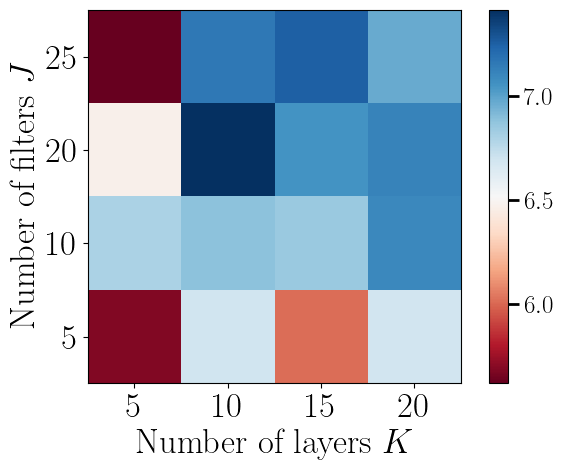

In [7]:
fig = plt.figure()
ax = fig.add_subplot(111)
im = ax.imshow(matrix_SNR / 4, cmap='RdBu')
ax.set_yticks(x_pos, y_ticks_filters)
ax.set_xticks(x_pos, x_ticks_layers)
ax.set_xlabel(r'Number of layers $K$', fontsize=25)
ax.set_ylabel(r'Number of filters $J$', fontsize=25)
ax.tick_params(axis='both', which='major', labelsize=25)
ax.invert_yaxis()
cbar = plt.colorbar(im, ax=ax)
cbar.ax.tick_params(labelsize=18, length=8, width=2)
plt.tight_layout()
plt.show()

### **Smoothness measure** $\left\lVert \mathsf{D}_1 \mathsf{R}\right\rVert $ **analysis**

Compute $\left\lVert \mathsf{D}_1 \mathsf{R}\right\rVert $ for each time series of the synthetic dataset for all configuration. 

In [5]:
matrix_D1R = np.zeros((4, 4))

config = TrainConfig(
    device = device,
    nepoch = 10,
    K_layer = 10,
    nb_filter = 20,

    #dataset = dico_datasets_omega_test['5'],

    dataset = f'../data/synthetic/test/omega5',
    R_init_type = 'ones',
)

for k_ind, k in enumerate(layer_list):
    for j_ind, j in enumerate(filter_list):
        matrix_D1R[j_ind, k_ind] = perf_D1R(config, dico_model[f'K{k}_J{j}'])

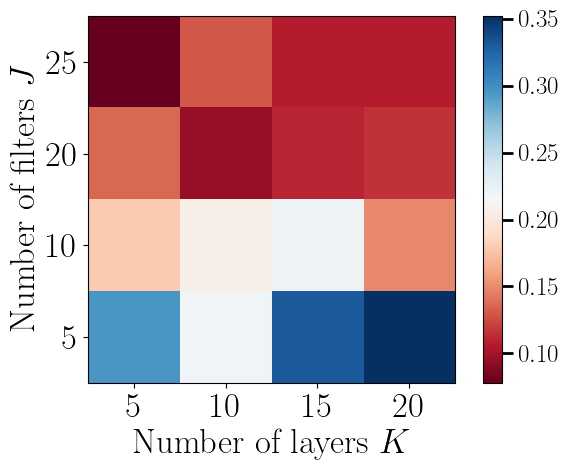

In [7]:
fig = plt.figure()
ax = fig.add_subplot(111)
im = ax.imshow(matrix_D1R, cmap='RdBu')
ax.set_yticks(x_pos, y_ticks_filters)
ax.set_xticks(x_pos, x_ticks_layers)
ax.set_xlabel(r'Number of layers $K$', fontsize=25)
ax.set_ylabel(r'Number of filters $J$', fontsize=25)
ax.tick_params(axis='both', which='major', labelsize=25)
ax.invert_yaxis()
cbar = plt.colorbar(im, ax=ax)
cbar.ax.tick_params(labelsize=18, length=8, width=2)
plt.tight_layout()
plt.show()